In [1]:
import sys, os, importlib
sys.path.append('../')

import scripts.analytics
import scripts.algorithms

f = sys.stdout
sys.stdout = open(os.devnull, 'w')

importlib.reload(scripts.analytics)
importlib.reload(scripts.algorithms)

import numpy as np
import pandas as pd

sys.stdout.close()
sys.stdout = f

In [2]:
name = "studentportuguese"
namex = "Portuguese"

d = 30

###knn
graphs = np.load("../graphs/"+name+"_knn_random.npy", allow_pickle=True)
###threshold
graphsz = np.load("../graphs/"+name+"_thresh_random.npy", allow_pickle=True)


# Standard model results

## Nearest neighbor

In [3]:
graphsinfor = []
for iz in range(len(graphs)):
    
    avg_left_deg, avg_left_pos_deg, avg_left_neg_deg, avg_right_deg, \
    avg_overlap,  avg_pos_overlap, avg_neg_overlap, only_pos, only_neg, \
    empty_adj, unipos  = scripts.analytics.getconnectivity_info(graphs[iz]["edges"], graphs[iz]["labels"])

    graphsinfor.append({
        "Dataset (d)": namex+" ("+ str(d) + ")",
        "kmax": graphs[iz]["k_max"], 
        "n": graphs[iz]['n'],
        "m": graphs[iz]['m'],
        "#+ves": len({t for t, l in graphs[iz]['labels'].items() if l == 1}),
        "#-ves": len({t for t, l in graphs[iz]['labels'].items() if l == -1}), 
        "avg LHSd": round(avg_left_deg,2), 
        "avg LHS+d": round(avg_left_pos_deg,2), 
        "avg LHS-d": round(avg_left_neg_deg,2),   
        "avg RHSd": round(avg_right_deg,2),          
        "avg overlap": round(avg_overlap,2), 
        "avg overlap+": round(avg_pos_overlap,2), 
        "avg overlap-": round(avg_neg_overlap,2), 
        "only+Ns": only_pos,
        "only-Ns": only_neg,
        "emptyNs": empty_adj,
        "uni+": unipos,
        "graphID": iz
    })

randomgraphsinfo = pd.DataFrame(graphsinfor)   
randomgraphsinfo



,Dataset (d),kmax,n,m,#+ves,#-ves,avg LHSd,avg LHS+d,avg LHS-d,avg RHSd,avg overlap,avg overlap+,avg overlap-,only+Ns,only-Ns,emptyNs,uni+,graphID
0,Portuguese (30),1,224,46,20,26,1.0,0.49,0.51,4.87,0.03,0.02,0.02,109,115,0,0,0
1,Portuguese (30),2,224,48,20,28,2.0,0.98,1.02,9.33,0.14,0.08,0.06,70,74,0,0,1
2,Portuguese (30),3,224,48,20,28,3.0,1.54,1.46,14.00,0.30,0.18,0.12,38,36,0,0,2
3,Portuguese (30),4,224,49,21,28,4.0,2.12,1.88,18.29,0.53,0.32,0.20,26,22,0,0,3
4,Portuguese (30),5,224,50,22,28,5.0,2.66,2.34,22.40,0.82,0.51,0.31,17,13,0,0,4
5,Portuguese (30),6,224,50,22,28,6.0,3.25,2.75,26.88,1.15,0.73,0.42,12,8,0,0,5
6,Portuguese (30),7,224,50,22,28,7.0,3.78,3.22,31.36,1.54,0.98,0.56,3,6,0,0,6
7,Portuguese (30),8,224,50,22,28,8.0,4.35,3.65,35.84,1.97,1.26,0.71,3,2,0,0,7
8,Portuguese (30),9,224,50,22,28,9.0,4.96,4.04,40.32,2.51,1.62,0.89,1,1,0,0,8
9,Portuguese (30),10,224,50,22,28,10.0,5.57,4.43,44.80,3.06,1.99,1.06,1,0,0,0,9


In [4]:
print(scripts.analytics.df_to_latex_preserve(randomgraphsinfo))

\begin{tabular}{llllllllllllllllllllllllll}
Dataset & (d) & kmax & n & m & #+ves & #-ves & avg & LHSd & avg & LHS+d & avg & LHS-d & avg & RHSd & avg & overlap & avg & overlap+ & avg & overlap- & only+Ns & only-Ns & emptyNs & uni+ & graphID \\
\hline
Portuguese & (30) & 1 & 224 & 46 & 20 & 26 & 1.0 & 0.49 & 0.51 & 4.87 & 0.03 & 0.02 & 0.02 & 109 & 115 & 0 & 0 & 0 \\
Portuguese & (30) & 2 & 224 & 48 & 20 & 28 & 2.0 & 0.98 & 1.02 & 9.33 & 0.14 & 0.08 & 0.06 & 70 & 74 & 0 & 0 & 1 \\
Portuguese & (30) & 3 & 224 & 48 & 20 & 28 & 3.0 & 1.54 & 1.46 & 14.00 & 0.30 & 0.18 & 0.12 & 38 & 36 & 0 & 0 & 2 \\
Portuguese & (30) & 4 & 224 & 49 & 21 & 28 & 4.0 & 2.12 & 1.88 & 18.29 & 0.53 & 0.32 & 0.20 & 26 & 22 & 0 & 0 & 3 \\
Portuguese & (30) & 5 & 224 & 50 & 22 & 28 & 5.0 & 2.66 & 2.34 & 22.40 & 0.82 & 0.51 & 0.31 & 17 & 13 & 0 & 0 & 4 \\
Portuguese & (30) & 6 & 224 & 50 & 22 & 28 & 6.0 & 3.25 & 2.75 & 26.88 & 1.15 & 0.73 & 0.42 & 12 & 8 & 0 & 0 & 5 \\
Portuguese & (30) & 7 & 224 & 50 & 22 & 28 & 7.0 

## Thresholding

In [5]:
graphsinforx = []
for ix in range(len(graphsz)):
    
    avg_left_degx, avg_left_pos_degx, avg_left_neg_degx, avg_right_degx, \
    avg_overlapx, avg_pos_overlapx, avg_neg_overlapx, only_posx, only_negx, \
    empty_adjx, uniposx  = scripts.analytics.getconnectivity_info(graphsz[ix]["edges"], graphsz[ix]["labels"])
        
    graphsinforx.append({
        "Dataset (d)":namex+" ("+ str(d) + ")",
        "r": graphsz[ix]["threshold"], 
        "n": graphsz[ix]['n'],
        "m": graphsz[ix]['m'],
        "#+ves": len({t for t, l in graphsz[ix]['labels'].items() if l == 1}),
        "#-ves": len({t for t, l in graphsz[ix]['labels'].items() if l == -1}), 
        "avg LHSd": round(avg_left_degx,2),  
        "avg LHS+d": round(avg_left_pos_degx,2),  
        "avg LHS-d": round(avg_left_neg_degx,2),   
        "avg RHSd": round(avg_right_degx,2),          
        "avg overlap": round(avg_overlapx,2), 
        "avg overlap+": round(avg_pos_overlapx,2), 
        "avg overlap-": round(avg_neg_overlapx,2), 
        "only+Ns": only_posx,
        "only-Ns": only_negx,
        "emptyNs": empty_adjx,
        "uni+": uniposx,
        "graphID": ix
    })

randomgraphsinfox = pd.DataFrame(graphsinforx)   
randomgraphsinfox


,Dataset (d),r,n,m,#+ves,#-ves,avg LHSd,avg LHS+d,avg LHS-d,avg RHSd,avg overlap,avg overlap+,avg overlap-,only+Ns,only-Ns,emptyNs,uni+,graphID
0,Portuguese (30),4.0,224,6,5,1,0.04,0.03,0.00,1.33,0.00,0.00,0.00,4,0,219,2,0
1,Portuguese (30),4.5,224,22,13,9,0.21,0.17,0.05,2.18,0.01,0.01,0.00,18,6,196,0,1
2,Portuguese (30),5.0,224,32,18,14,0.67,0.54,0.12,4.66,0.06,0.06,0.00,32,8,169,0,2
3,Portuguese (30),5.5,224,39,20,19,1.50,1.04,0.46,8.62,0.15,0.12,0.02,30,28,129,0,3
4,Portuguese (30),6.0,224,44,20,24,3.43,2.13,1.30,17.48,0.47,0.33,0.14,26,40,77,0,4
5,Portuguese (30),6.5,224,48,21,27,7.12,4.31,2.80,33.21,1.66,1.13,0.52,15,29,41,0,5
6,Portuguese (30),7.0,224,49,21,28,12.69,7.17,5.52,58.02,4.53,2.86,1.66,6,22,20,0,6
7,Portuguese (30),7.5,224,50,22,28,19.76,10.53,9.23,88.52,9.80,5.79,4.01,4,16,7,0,7
8,Portuguese (30),8.0,224,50,22,28,27.27,13.72,13.55,122.18,17.22,9.36,7.86,1,7,3,0,8
9,Portuguese (30),8.5,224,50,22,28,34.06,16.52,17.54,152.60,25.44,13.16,12.27,0,3,1,0,9


In [6]:
print(scripts.analytics.df_to_latex_preserve(randomgraphsinfox))

\begin{tabular}{llllllllllllllllllllllllll}
Dataset & (d) & r & n & m & #+ves & #-ves & avg & LHSd & avg & LHS+d & avg & LHS-d & avg & RHSd & avg & overlap & avg & overlap+ & avg & overlap- & only+Ns & only-Ns & emptyNs & uni+ & graphID \\
\hline
Portuguese & (30) & 4.0 & 224 & 6 & 5 & 1 & 0.04 & 0.03 & 0.00 & 1.33 & 0.00 & 0.00 & 0.00 & 4 & 0 & 219 & 2 & 0 \\
Portuguese & (30) & 4.5 & 224 & 22 & 13 & 9 & 0.21 & 0.17 & 0.05 & 2.18 & 0.01 & 0.01 & 0.00 & 18 & 6 & 196 & 0 & 1 \\
Portuguese & (30) & 5.0 & 224 & 32 & 18 & 14 & 0.67 & 0.54 & 0.12 & 4.66 & 0.06 & 0.06 & 0.00 & 32 & 8 & 169 & 0 & 2 \\
Portuguese & (30) & 5.5 & 224 & 39 & 20 & 19 & 1.50 & 1.04 & 0.46 & 8.62 & 0.15 & 0.12 & 0.02 & 30 & 28 & 129 & 0 & 3 \\
Portuguese & (30) & 6.0 & 224 & 44 & 20 & 24 & 3.43 & 2.13 & 1.30 & 17.48 & 0.47 & 0.33 & 0.14 & 26 & 40 & 77 & 0 & 4 \\
Portuguese & (30) & 6.5 & 224 & 48 & 21 & 27 & 7.12 & 4.31 & 2.80 & 33.21 & 1.66 & 1.13 & 0.52 & 15 & 29 & 41 & 0 & 5 \\
Portuguese & (30) & 7.0 & 224 & 49 

# Load the algorithmic results

In [7]:
greedy_bruteforce_algosdf = pd.read_csv("./sm_results/"+name+"_knn_greedy_rdm_bruteforce.csv")
all_bruteforce = pd.read_csv("./sm_results/"+name+"_knn_allbruteforce.csv")

greedy_bruteforce_algosdfz = pd.read_csv("./sm_results/"+name+"_thresh_greedy_rdm_bruteforce.csv")
all_bruteforcez = pd.read_csv("./sm_results/"+name+"_thresh_allbruteforce.csv")


In [8]:
summary_df = pd.read_csv("./sm_results/"+name+"_knn_summary.csv")
greedyalgo_df = pd.read_csv("./sm_results/"+name+"_knn_greedyheuristic.csv")
randomalgo_df = pd.read_csv("./sm_results/"+name+"_knn_randomheuristic.csv")


summary_dfx = pd.read_csv("./sm_results/"+name+"_thresh_summary.csv")
greedyalgo_dfx = pd.read_csv("./sm_results/"+name+"_thresh_greedyheuristic.csv")
randomalgo_dfx = pd.read_csv("./sm_results/"+name+"_thresh_randomheuristic.csv")


# Compute social welfare given an empty set

## Nearest neighbor

In [9]:
results_knn = []

for lx in range(len(graphs)):

    r_edges_randomx  = graphs[lx]["edges"]
    r_labels_randomx = graphs[lx]["labels"]
    
    
    ###############
    Sx = set()
    cur_utility = scripts.algorithms.F_S(r_edges_randomx, r_labels_randomx, Sx)

    
    ###############
    for Kx in [1, 2, 3, 4, 5]:
        
        #######
        results_knn.append({
            "kmax": graphs[lx]["k_max"],
            "graphid": lx,
            "K": Kx,
            "F(So)": cur_utility


        })


mddfa = summary_df.merge(pd.DataFrame(results_knn), on=["kmax", "graphid", "K"], how="left")

mdf = mddfa.merge(greedy_bruteforce_algosdf[["kmax", "graphid", "K", "F(S*)"]], on=["kmax", "graphid", "K"], how="left")

pd.DataFrame(results_knn).tail()


,kmax,graphid,K,F(So)
45,10,9,1,124.8
46,10,9,2,124.8
47,10,9,3,124.8
48,10,9,4,124.8
49,10,9,5,124.8


## Thresholding

In [10]:
results_thresh = []

for lz in range(len(graphsz)):

    r_edges_randomz  = graphsz[lz]["edges"]
    r_labels_randomz = graphsz[lz]["labels"]
    
    
    ###############
    Sz = set()
    cur_utilityz = scripts.algorithms.F_S(r_edges_randomz, r_labels_randomz, Sz)

    
    ###############
    for Kz in [1, 2, 3, 4, 5]:
        
        #######
        results_thresh.append({
            "r": graphsz[lz]["threshold"],
            "graphid": lz,
            "K": Kz,
            "F(So)": cur_utilityz


        })

        
mddfaz = summary_dfx.merge(pd.DataFrame(results_thresh), on=["r", "graphid", "K"], how="left")

mdfz = mddfaz.merge(greedy_bruteforce_algosdfz[["r", "graphid", "K", "F(S*)"]], on=["r", "graphid", "K"], how="left")

pd.DataFrame(results_thresh).tail()


,r,graphid,K,F(So)
60,10.0,12,1,99.810802
61,10.0,12,2,99.810802
62,10.0,12,3,99.810802
63,10.0,12,4,99.810802
64,10.0,12,5,99.810802


# Standard model results plots

## Nearest neighbor

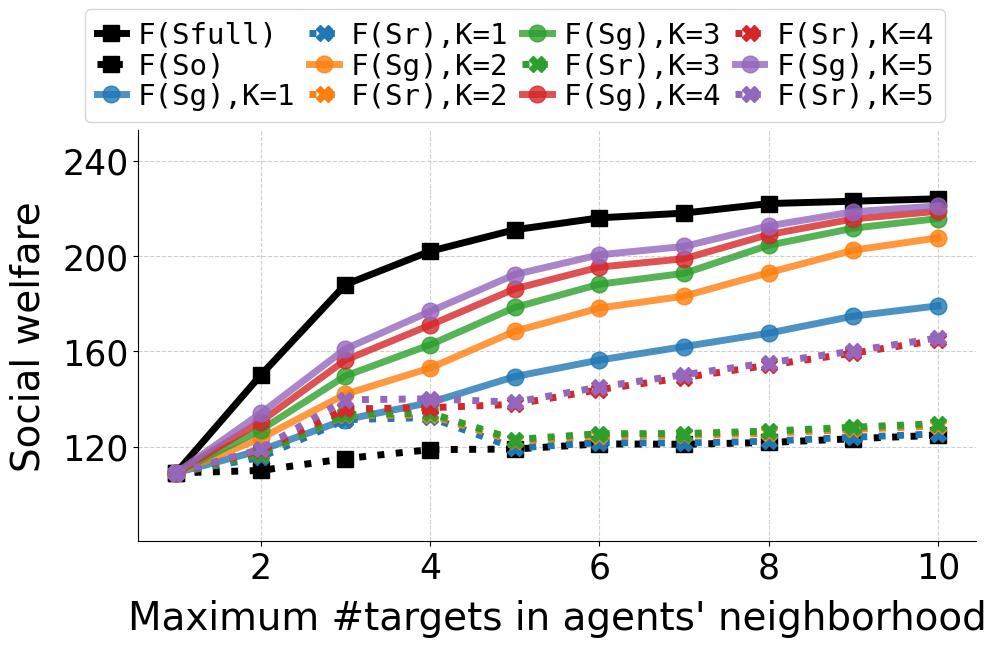

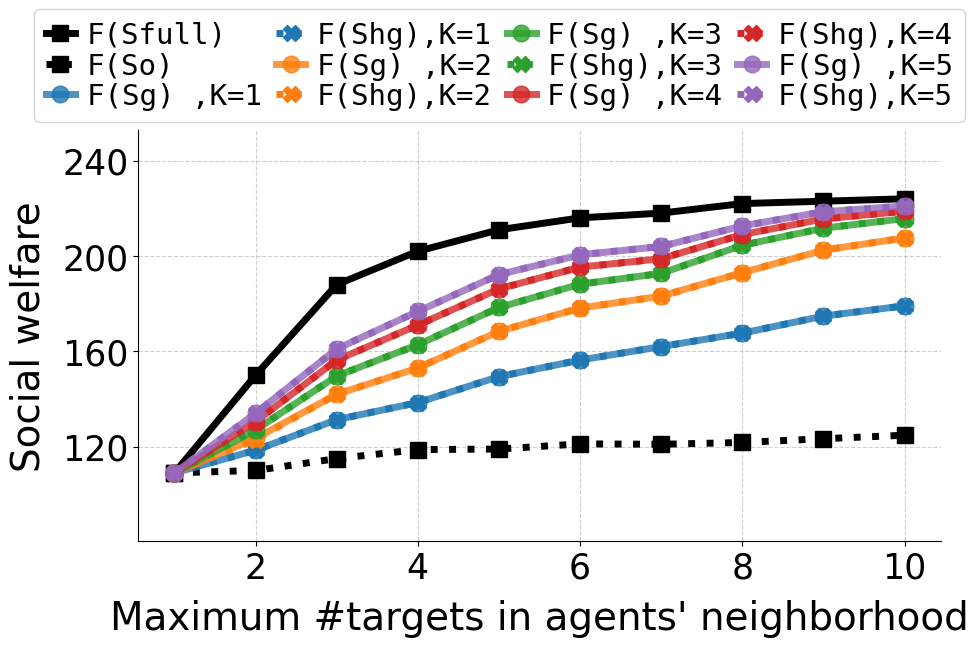

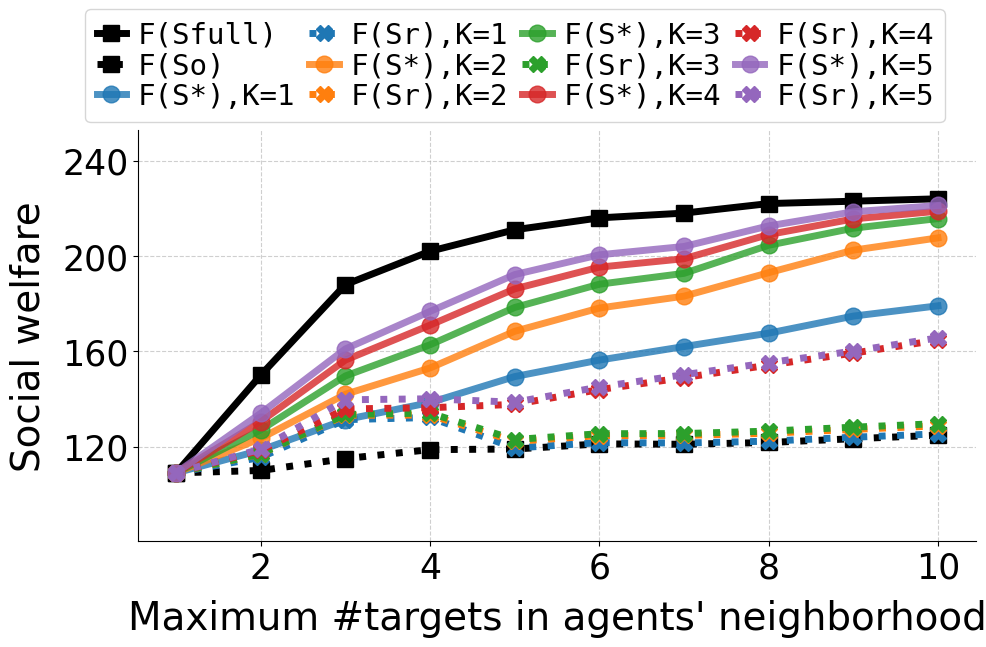

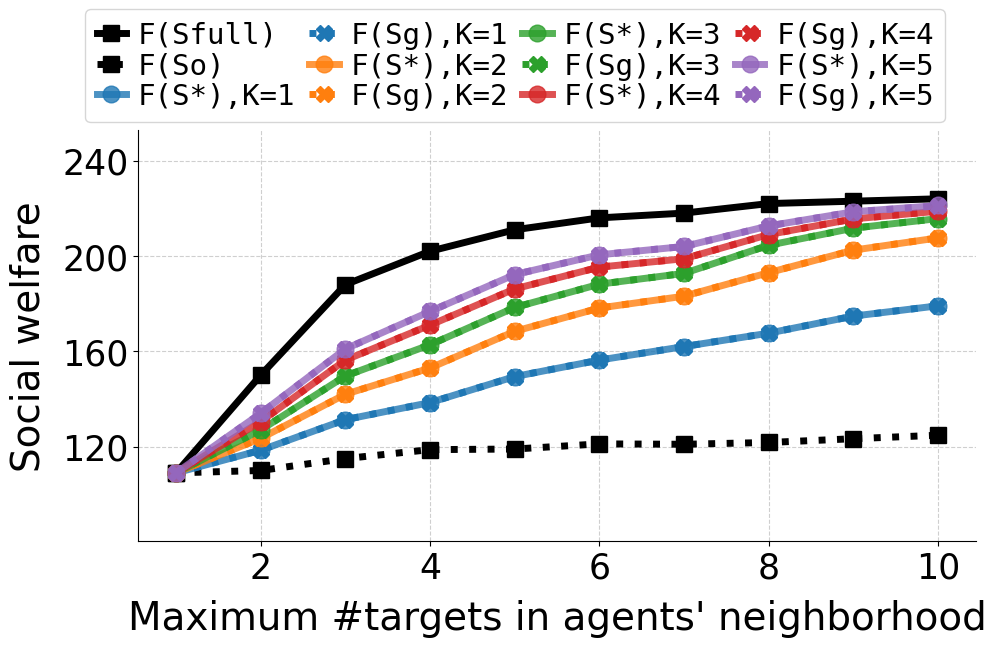

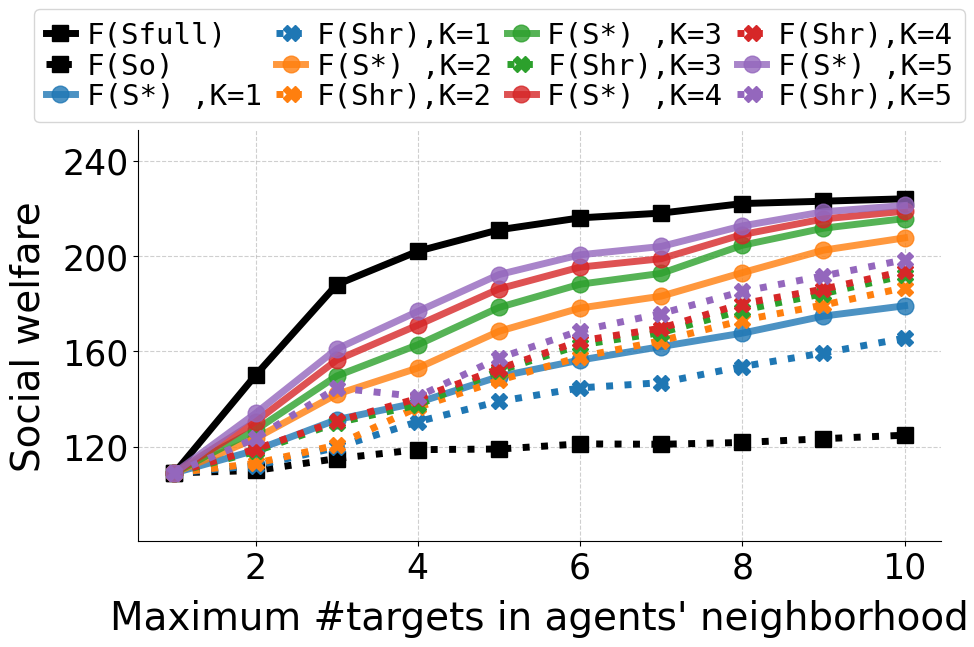

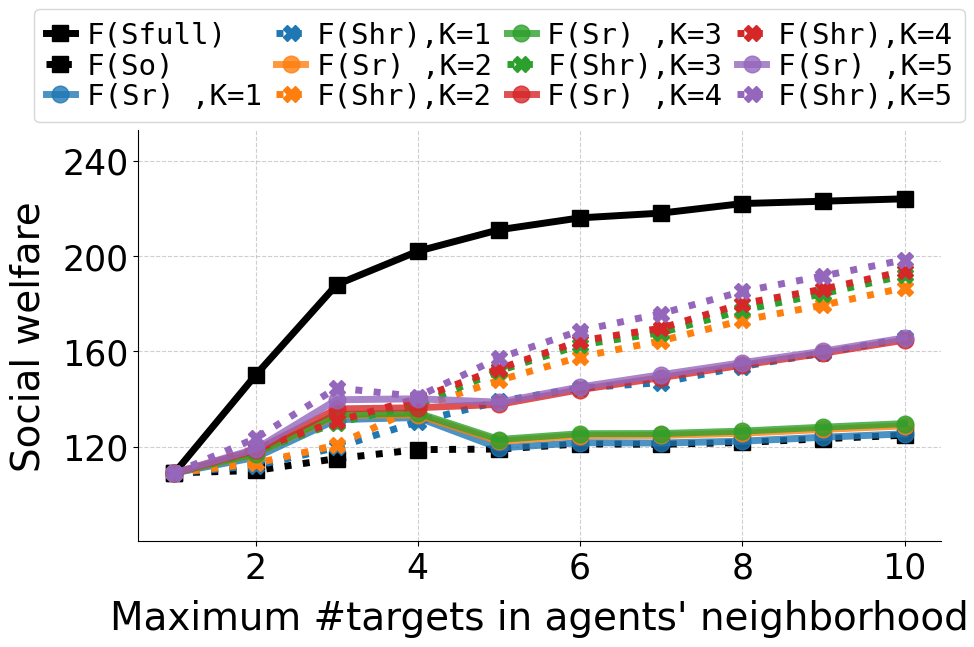

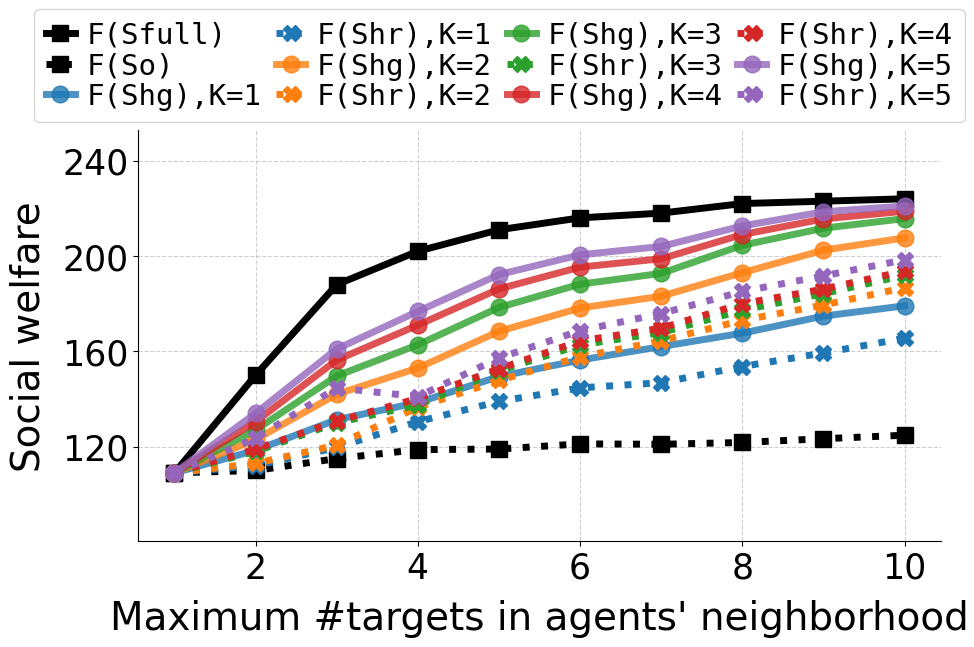

In [11]:
daz1 = mdf[["K", "F(Sg)", "F(Sr)", "kmax", "F(Sgfull)", "F(So)", "F(S*)"]]
scripts.analytics.sm_results_plot(daz1, x_col="kmax", ycol1="F(Sg)", ycol2="F(Sr)", ycol3="F(Sgfull)", 
                                   ycol4="F(So)", ycol1_name="F(Sg),", ycol2_name="F(Sr),", ycol3_name="F(Sfull)", 
                                   ycol4_name="F(So)", ycol5="F(S*)", ycol5_name="F(S*)",  
                                   save_as="./sm_results/figures/aplot_"+namex+"_sr_sg_knn.pdf",
                                   figsize=(10, 7), showfig=True)


    
############################
daz2 = mdf[["K", "F(Sg)", "F(Sg+ U Sg-)*", "kmax", "F(Sgfull)", "F(So)", "F(S*)"]]
scripts.analytics.sm_results_plot(daz2, x_col="kmax", ycol1="F(Sg)", ycol2="F(Sg+ U Sg-)*", ycol3="F(Sgfull)", 
                                   ycol4="F(So)", ycol1_name="F(Sg) ,", ycol2_name="F(Shg),", ycol3_name="F(Sfull)", 
                                   ycol4_name="F(So)", ycol5="F(S*)", ycol5_name="F(S*)",   
                                   save_as="./sm_results/figures/aplot_"+namex+"_sg_shg_knn.pdf",
                                   figsize=(10, 7), showfig=True)



############################
daz144 = mdf[["K", "F(Sg)", "F(Sr)", "kmax", "F(Sgfull)", "F(So)", "F(S*)"]]
scripts.analytics.sm_results_plot(daz144, x_col="kmax", ycol1="F(S*)", ycol2="F(Sr)", ycol3="F(Sgfull)", 
                                   ycol4="F(So)", ycol1_name="F(S*),", ycol2_name="F(Sr),", ycol3_name="F(Sfull)", 
                                   ycol4_name="F(So)", 
                                   save_as="./sm_results/figures/aplot_"+namex+"_star_sr_knn.pdf",
                                   figsize=(10, 7), showfig=True)


    
############################
daz244 = mdf[["K", "F(Sg)", "F(Sg+ U Sg-)*", "kmax", "F(Sgfull)", "F(So)", "F(S*)"]]
scripts.analytics.sm_results_plot(daz244, x_col="kmax", ycol1="F(S*)", ycol2="F(Sg)", ycol3="F(Sgfull)", 
                                   ycol4="F(So)", ycol1_name="F(S*),", ycol2_name="F(Sg),", ycol3_name="F(Sfull)", 
                                   ycol4_name="F(So)", 
                                   save_as="./sm_results/figures/aplot_"+namex+"_star_sg_knn.pdf",
                                   figsize=(10, 7), showfig=True)


    
############################
daz245 = mdf[["K", "F(Sg)", "F(Sr+ U Sr-)*", "kmax", "F(Sgfull)", "F(So)", "F(S*)"]]
scripts.analytics.sm_results_plot(daz245, x_col="kmax", ycol1="F(S*)", ycol2="F(Sr+ U Sr-)*", ycol3="F(Sgfull)", 
                                   ycol4="F(So)", ycol1_name="F(S*) ,", ycol2_name="F(Shr),", ycol3_name="F(Sfull)", 
                                   ycol4_name="F(So)", 
                                   save_as="./sm_results/figures/aplot_"+namex+"_star_shr_knn.pdf",
                                   figsize=(10, 7), showfig=True)


    
###########################
daz3 = mdf[["K", "F(Sr)", "F(Sr+ U Sr-)*", "kmax", "F(Sgfull)", "F(So)", "F(S*)"]]

scripts.analytics.sm_results_plot(daz3, x_col="kmax", ycol1="F(Sr)", ycol2="F(Sr+ U Sr-)*", ycol3="F(Sgfull)", 
                                   ycol4="F(So)", ycol1_name="F(Sr) ,", ycol2_name="F(Shr),", ycol3_name="F(Sfull)", 
                                   ycol4_name="F(So)", ycol5="F(S*)", ycol5_name="F(S*)",  
                                   save_as="./sm_results/figures/aplot_"+namex+"_sr_shr_knn.pdf",
                                   figsize=(10, 7), showfig=True)



###########################
daz4 = mdf[["K", "F(Sg+ U Sg-)*", "F(Sr+ U Sr-)*", "kmax", "F(Sgfull)", "F(So)", "F(S*)"]]

scripts.analytics.sm_results_plot(daz4, x_col="kmax", ycol1="F(Sg+ U Sg-)*", ycol2="F(Sr+ U Sr-)*", ycol3="F(Sgfull)", 
                                   ycol4="F(So)", ycol1_name="F(Shg),", ycol2_name="F(Shr),", ycol3_name="F(Sfull)", 
                                   ycol4_name="F(So)", ycol5="F(S*)", ycol5_name="F(S*)",  
                                   save_as="./sm_results/figures/aplot_"+namex+"_shg_shr_knn.pdf",
                                   figsize=(10, 7), showfig=True)

    
    

## Thresholding

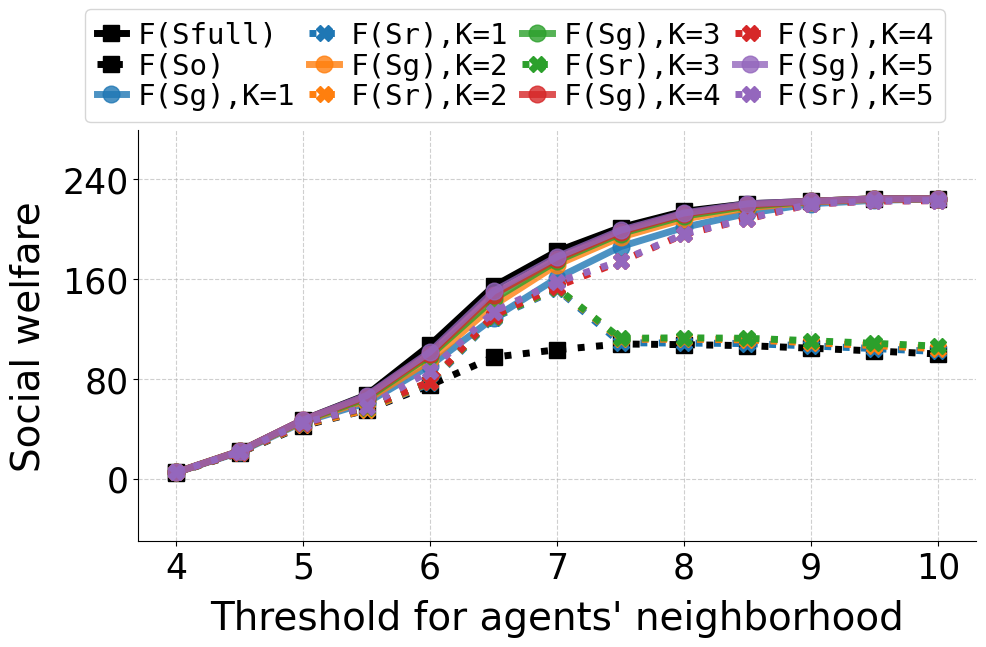

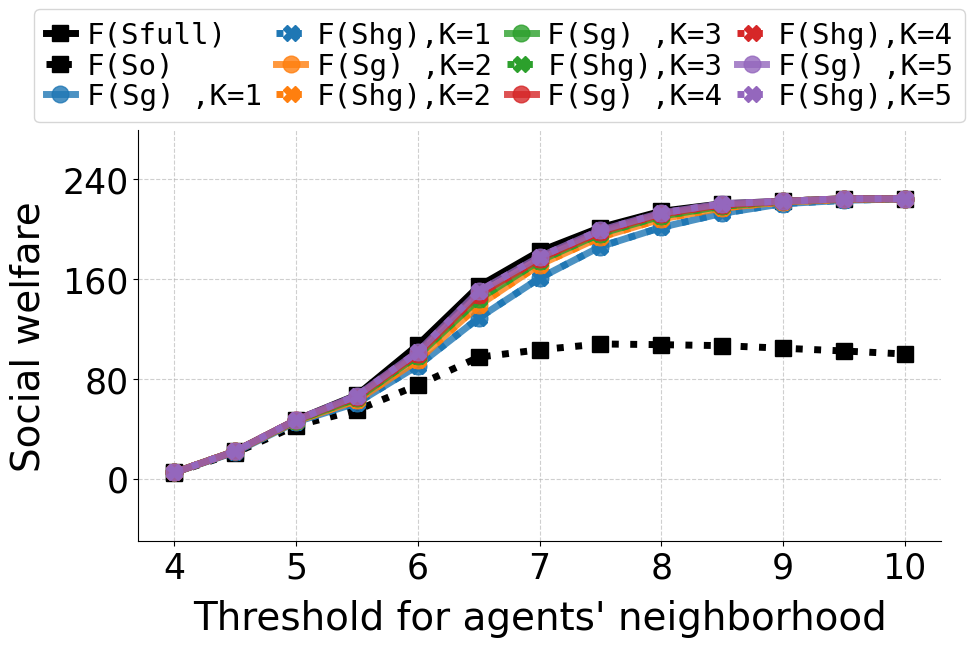

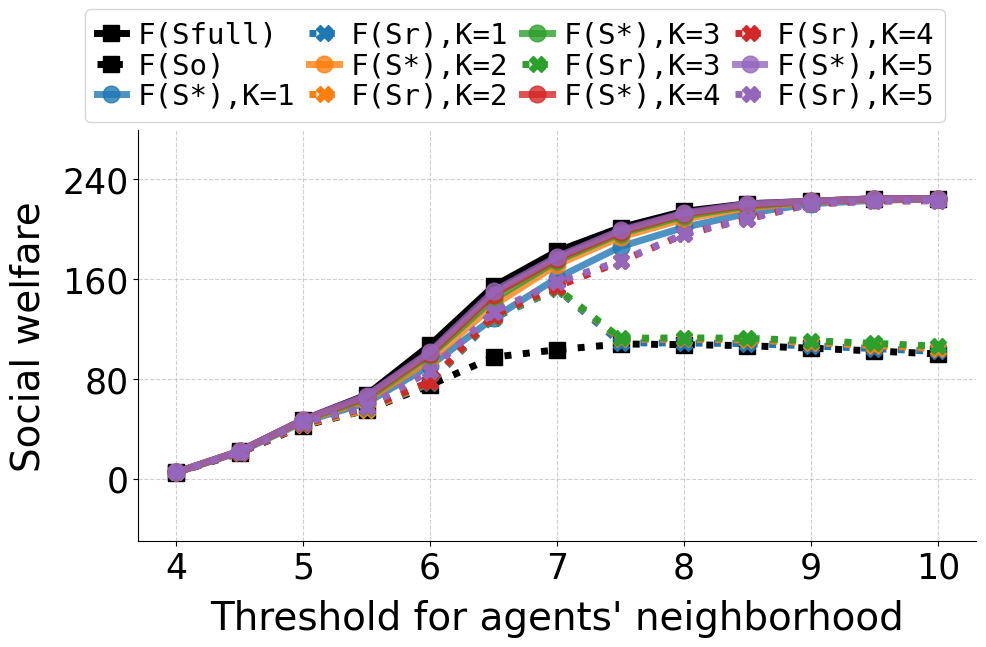

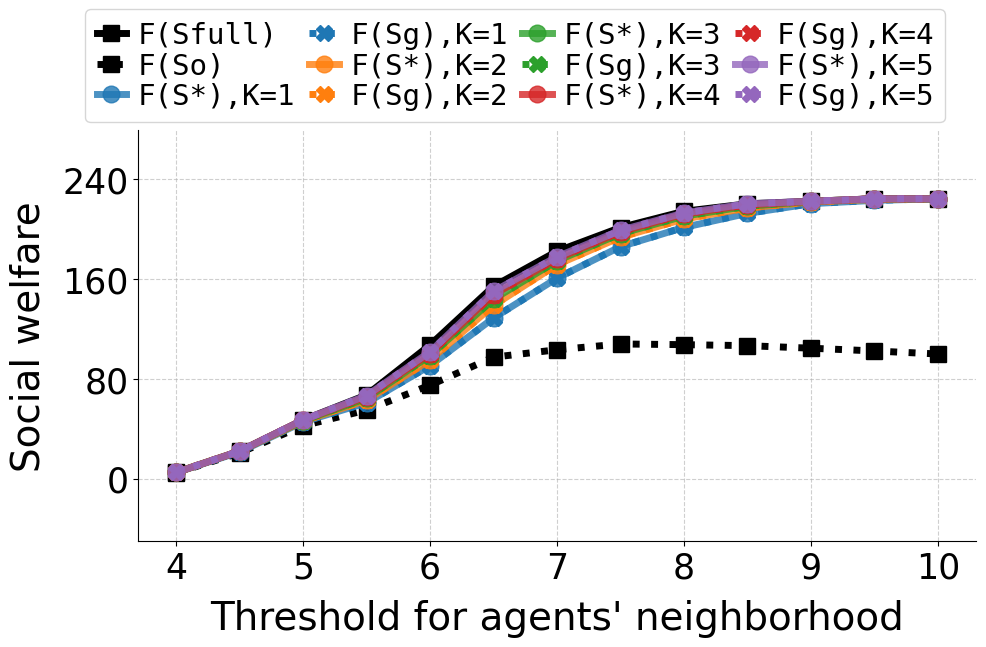

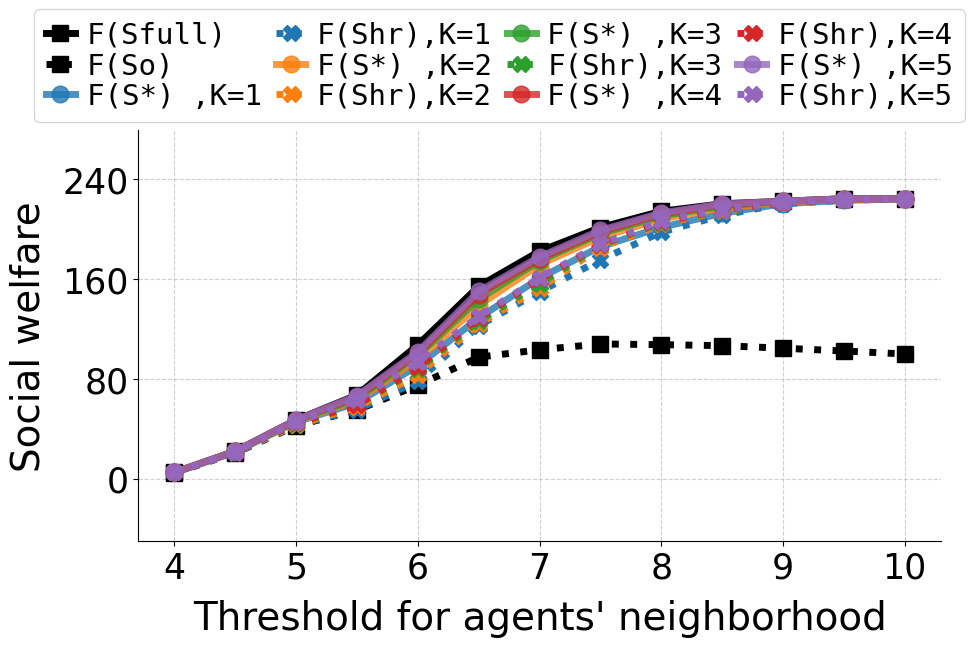

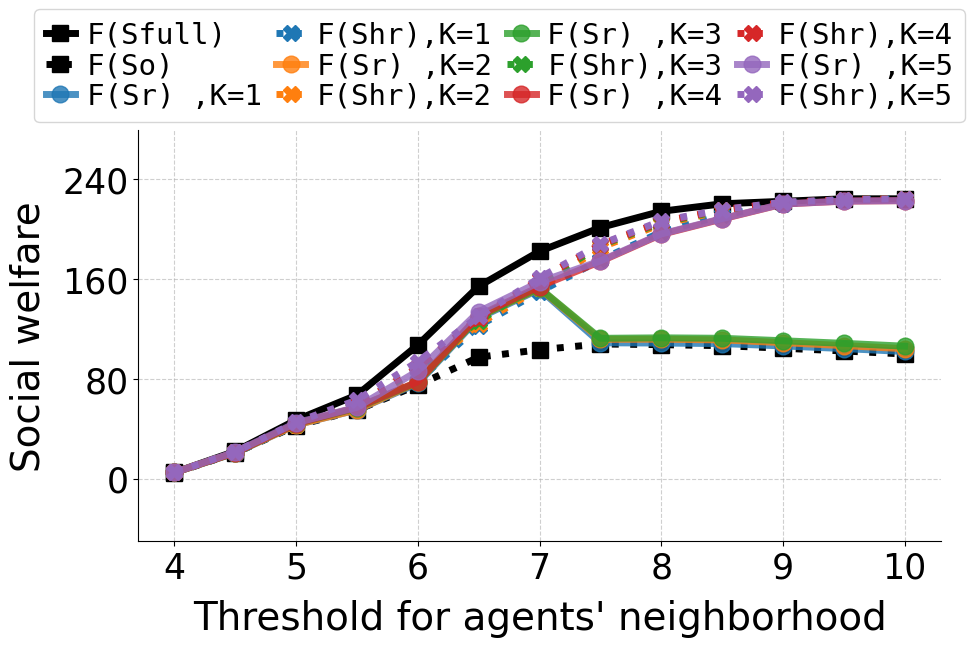

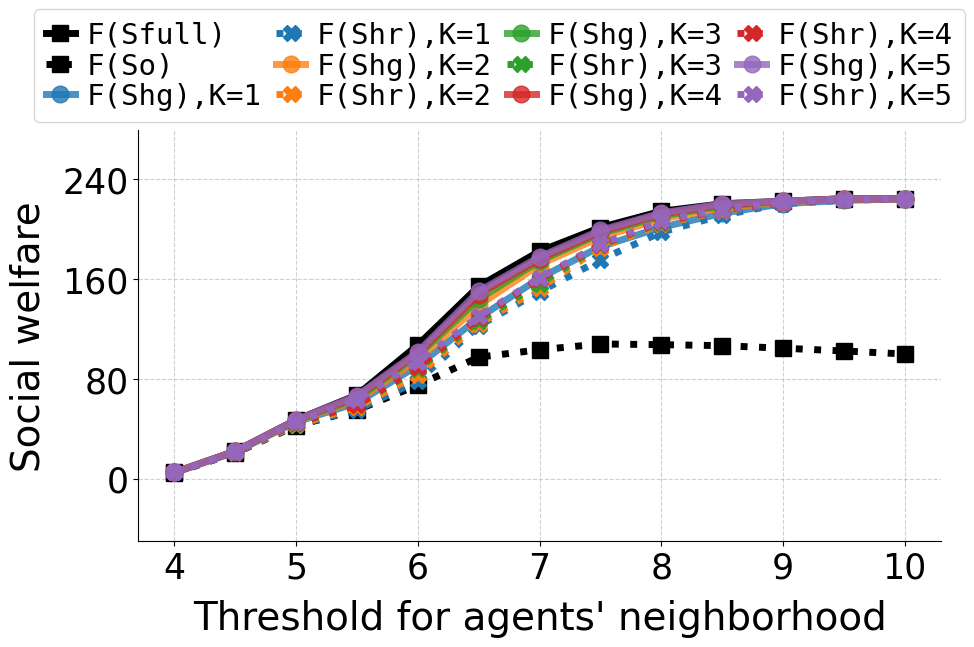

In [12]:
daz11 = mdfz[["K", "F(Sg)", "F(Sr)", "r", "F(Sgfull)", "F(So)", "F(S*)"]]
scripts.analytics.sm_results_plot(daz11, x_col="r", ycol1="F(Sg)", ycol2="F(Sr)", ycol3="F(Sgfull)", 
                                   ycol4="F(So)", ycol1_name="F(Sg),", ycol2_name="F(Sr),", ycol3_name="F(Sfull)", 
                                   ycol4_name="F(So)", ycol5="F(S*)", ycol5_name="F(S*)",  
                                   save_as="./sm_results/figures/aplot_"+namex+"_sr_sg_thresh.pdf",
                                   figsize=(10, 7), showfig=True)


    
############################
daz22 = mdfz[["K", "F(Sg)", "F(Sg+ U Sg-)*", "r", "F(Sgfull)", "F(So)", "F(S*)"]]
scripts.analytics.sm_results_plot(daz22, x_col="r", ycol1="F(Sg)", ycol2="F(Sg+ U Sg-)*", ycol3="F(Sgfull)", 
                                   ycol4="F(So)", ycol1_name="F(Sg) ,", ycol2_name="F(Shg),", ycol3_name="F(Sfull)", 
                                   ycol4_name="F(So)", ycol5="F(S*)", ycol5_name="F(S*)",  
                                   save_as="./sm_results/figures/aplot_"+namex+"_sg_shg_thresh.pdf",
                                   figsize=(10, 7), showfig=True)



############################
daz1144 = mdfz[["K", "F(Sg)", "F(Sr)", "r", "F(Sgfull)", "F(So)", "F(S*)"]]
scripts.analytics.sm_results_plot(daz1144, x_col="r", ycol1="F(S*)", ycol2="F(Sr)", ycol3="F(Sgfull)", 
                                   ycol4="F(So)", ycol1_name="F(S*),", ycol2_name="F(Sr),", ycol3_name="F(Sfull)", 
                                   ycol4_name="F(So)",
                                   save_as="./sm_results/figures/aplot_"+namex+"_star_sr_thresh.pdf",
                                   figsize=(10, 7), showfig=True)


    
############################
daz2244 = mdfz[["K", "F(Sg)", "F(Sg+ U Sg-)*", "r", "F(Sgfull)", "F(So)", "F(S*)"]]
scripts.analytics.sm_results_plot(daz2244, x_col="r", ycol1="F(S*)", ycol2="F(Sg)", ycol3="F(Sgfull)", 
                                   ycol4="F(So)", ycol1_name="F(S*),", ycol2_name="F(Sg),", ycol3_name="F(Sfull)", 
                                   ycol4_name="F(So)", 
                                   save_as="./sm_results/figures/aplot_"+namex+"_star_sg_thresh.pdf",
                                   figsize=(10, 7), showfig=True)



############################
daz2245 = mdfz[["K", "F(Sg)", "F(Sr+ U Sr-)*", "r", "F(Sgfull)", "F(So)", "F(S*)"]]
scripts.analytics.sm_results_plot(daz2245, x_col="r", ycol1="F(S*)", ycol2="F(Sr+ U Sr-)*", ycol3="F(Sgfull)", 
                                   ycol4="F(So)", ycol1_name="F(S*) ,", ycol2_name="F(Shr),", ycol3_name="F(Sfull)", 
                                   ycol4_name="F(So)", 
                                   save_as="./sm_results/figures/aplot_"+namex+"_star_shr_thresh.pdf",
                                   figsize=(10, 7), showfig=True)



###########################
daz33 = mdfz[["K", "F(Sr)", "F(Sr+ U Sr-)*", "r", "F(Sgfull)", "F(So)", "F(S*)"]]

scripts.analytics.sm_results_plot(daz33, x_col="r", ycol1="F(Sr)", ycol2="F(Sr+ U Sr-)*", ycol3="F(Sgfull)", 
                                   ycol4="F(So)", ycol1_name="F(Sr) ,", ycol2_name="F(Shr),", ycol3_name="F(Sfull)", 
                                   ycol4_name="F(So)", ycol5="F(S*)", ycol5_name="F(S*)",  
                                   save_as="./sm_results/figures/aplot_"+namex+"_sr_shr_thresh.pdf",
                                   figsize=(10, 7), showfig=True)



###########################
daz44 = mdfz[["K", "F(Sg+ U Sg-)*", "F(Sr+ U Sr-)*", "r", "F(Sgfull)", "F(So)", "F(S*)"]]

scripts.analytics.sm_results_plot(daz44, x_col="r", ycol1="F(Sg+ U Sg-)*", ycol2="F(Sr+ U Sr-)*", ycol3="F(Sgfull)", 
                                   ycol4="F(So)", ycol1_name="F(Shg),", ycol2_name="F(Shr),", ycol3_name="F(Sfull)", 
                                   ycol4_name="F(So)", ycol5="F(S*)", ycol5_name="F(S*)",  
                                   save_as="./sm_results/figures/aplot_"+namex+"_shg_shr_thresh.pdf",
                                   figsize=(10, 7), showfig=True)


  